# Ground-truth sparsity of splice-junction-derived immunogenicity

**Issue [#737](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/737)** · leaf of parent **[#680](https://github.com/Jin-HoMLee/splice-neoepitope-pipeline/issues/680)** (carries #680 AC#4).

The functional-validation base for splice-junction-derived neoantigens is critically thin and source-clustered. This notebook quantifies that sparsity directly from the curated registry (`registry.tsv`), the field-wide assembly of every published peptide that passes **both** gates:

- **Gate 1** - the peptide is splice-junction-derived (alt-splicing / intron-retention / exon-TE junction, *not* an SNV/indel neoantigen).
- **Gate 2** - its T-cell immunogenicity was *measured* in a functional assay (IFN-γ, tetramer, cytotoxicity, 4-1BB), not predicted.

Outputs (figures + a machine-readable stats JSON) are written to `outputs/` and are the canonical source for the experiment deck (`slides.qmd`) and the writeup (`sparsity_writeup.md`).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# EXP = the shared registry/core dir (holds registry.tsv + decoy_negatives/).
# This notebook lives in the sub-issue analysis subfolder issue_737_sparsity/, so
# the registry is one level up. Resolve robustly whether run from the subfolder,
# the registry dir itself, or the repo root.
REG_DIR = "research/experiments/issue_680_splice_immunogenicity_registry"
HERE = Path.cwd()
if (HERE / "registry.tsv").exists():
    EXP = HERE                       # cwd is the registry dir
elif (HERE.parent / "registry.tsv").exists():
    EXP = HERE.parent                # cwd is an analysis subfolder (e.g. issue_737_sparsity/)
else:
    EXP = Path(REG_DIR)              # cwd is the repo root
# Outputs are co-located with this notebook, not in the shared core.
OUT = EXP / "issue_737_sparsity" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

reg = pd.read_csv(EXP / "registry.tsv", sep="\t")
print("registry rows:", len(reg))
stats = {}  # accumulates every headline number -> issue_737_sparsity/outputs/sparsity_stats.json

registry rows: 97


## 1 · The dual-gate set

Tiers that pass both gates (splice-derived **and** functionally assayed) are the registry's `functional-*`, `candidate-negative`, and `hard-negative-true-splice` rows. The **scorable positives** - the rows usable for a ranking metric (a published sequence + an HLA restriction + a positive functional readout) - are exactly `tier == functional-scorable`.

In [2]:
GATE2_TIERS = ["functional-scorable", "functional-nonscorable",
               "candidate-negative", "hard-negative-true-splice"]
dual_gate = reg[reg.tier.isin(GATE2_TIERS)]
scorable  = reg[reg.tier == "functional-scorable"]

stats["registry_rows_total"] = int(len(reg))
stats["dual_gate_rows"] = int(len(dual_gate))
stats["scorable_positives"] = int(len(scorable))

print("dual-gate (both gates pass):", len(dual_gate))
print("scorable positives:", len(scorable))
print("\ntier breakdown (all rows):")
print(reg.tier.value_counts().to_string())

dual-gate (both gates pass): 95
scorable positives: 82

tier breakdown (all rows):
tier
functional-scorable            82
candidate-negative              8
functional-nonscorable          4
presentation-prevalence         1
hard-negative-true-splice       1
negative-control-not-splice     1


## 2 · Concentration metrics

For a categorical contribution vector (peptides per study / allele / mechanism) we report three concentration measures:

- **Top share** - fraction from the single largest contributor.
- **HHI** (Herfindahl-Hirschman index, $\sum p_i^2$) - 1/k under perfect spread, 1.0 for a monopoly.
- **Effective number** (inverse-Simpson, $1/\text{HHI}$) - how many *equally-weighted* contributors the diversity is worth. This is the honest headline: 11 studies that are really worth ~3.9.

In [3]:
def concentration(series, label):
    # fillna *inside* the helper so every axis is treated identically:
    # value_counts() silently drops NaN, which would shrink the denominator
    # n below the row count and inflate the effective number. The assert is a
    # loud backstop if a future NaN slips a category we forgot to map.
    series = series.fillna("(unresolved)")
    vc = series.value_counts()
    n = int(vc.sum()); k = int(len(vc))
    assert n == len(series), f"{label}: {len(series)-n} rows dropped from denominator"
    shares = vc / n
    hhi = float((shares ** 2).sum())
    eff = float(1 / hhi)
    top_share = float(shares.iloc[0])
    top2 = float(vc.iloc[:2].sum() / n) if k >= 2 else top_share
    rec = dict(n=n, distinct=k, top=vc.index[0], top_share=round(top_share, 3),
               top2_share=round(top2, 3), hhi=round(hhi, 3),
               effective_n=round(eff, 2), counts=vc.to_dict())
    print(f"[{label}] n={n} distinct={k} top='{vc.index[0]}' {top_share:.1%} "
          f"top2={top2:.1%} HHI={hhi:.3f} effective#={eff:.2f}")
    return rec

# Collapse known source-string splits to one canonical study label.
def canon_study(s):
    s = str(s)
    if s.startswith("SNAF"): return "SNAF (Li 2024)"
    if s.startswith("IRIS"): return "IRIS (Pan/Xing)"
    return s
scorable = scorable.assign(study=scorable.source.map(canon_study))

# All three axes now go through the same fillna+assert guard in concentration().
stats["by_study"]     = concentration(scorable.study, "study")
stats["by_allele"]    = concentration(scorable.hla, "allele")
stats["by_mechanism"] = concentration(scorable.splice_mechanism_canonical, "mechanism")

[study] n=82 distinct=11 top='Bigot 2021 (SF3B1 UM)' 42.7% top2=64.6% HHI=0.254 effective#=3.93
[allele] n=82 distinct=6 top='HLA-A*02:01' 89.0% top2=93.9% HHI=0.796 effective#=1.26
[mechanism] n=82 distinct=10 top='alt_3p_ss' 39.0% top2=63.4% HHI=0.238 effective#=4.20


## 3 · Negative-set scarcity vs powered-probe need

The positives are plentiful enough to *rank*; the **negatives are the binding reagent**. Field-wide there is exactly **one** hard true-negative (MS-presented **and** functional-assay-negative) plus 8 *soft* negatives (failed-to-prime in healthy-donor in-vitro sensitization - a categorically weaker claim). Pooling the 13 Tier-2 presented-but-untested decoys raises the *usable-decoy* ceiling to 22, but those are untested, not tested-negative.

We size the negative requirement with the Hanley-McNeil AUC power formula (detect a true AUC vs the 0.5 null, balanced arms, two-sided $\alpha=0.05$, 80% power).

In [4]:
negs = reg[reg.label == "negative"]
hard = int((negs.evidence_strength == "hard").sum())
soft = int((negs.evidence_strength == "soft").sum())
decoys = pd.read_csv(EXP / "decoy_negatives" / "presented_decoys_681.tsv", sep="\t")
tier2 = int(len(decoys))

stats["negatives"] = dict(hard_true_negative=hard, soft_negative=soft,
                          tested_total=hard + soft, tier2_presented_untested=tier2,
                          usable_decoy_ceiling=hard + soft + tier2)
print(f"hard true-negatives: {hard}")
print(f"soft negatives (failed-to-prime IVS): {soft}")
print(f"tested-negative total: {hard + soft}")
print(f"Tier-2 presented (untested) decoys: {tier2}")
print(f"pooled usable-decoy ceiling: {hard + soft + tier2}")

def n_per_arm(auc, alpha=0.05, power=0.80, null=0.5):
    Q1 = auc / (2 - auc); Q2 = 2 * auc * auc / (1 + auc)
    V1 = (Q1 - auc**2) + (Q2 - auc**2)
    q1n = null / (2 - null); q2n = 2 * null * null / (1 + null)
    V0 = (q1n - null**2) + (q2n - null**2)
    za, zb = norm.ppf(1 - alpha/2), norm.ppf(power)
    return int(np.ceil(((za*np.sqrt(V0) + zb*np.sqrt(V1)) / (auc - null))**2))

power_tbl = {auc: n_per_arm(auc) for auc in (0.70, 0.75, 0.80, 0.85)}
stats["power_n_per_arm"] = power_tbl
print("\nAUC -> negatives (and positives) needed per arm, 80% power:")
for a, n in power_tbl.items():
    print(f"  AUC={a}: {n} per arm")

hard true-negatives: 1
soft negatives (failed-to-prime IVS): 8
tested-negative total: 9
Tier-2 presented (untested) decoys: 13
pooled usable-decoy ceiling: 22

AUC -> negatives (and positives) needed per arm, 80% power:
  AUC=0.7: 31 per arm
  AUC=0.75: 19 per arm
  AUC=0.8: 13 per arm
  AUC=0.85: 9 per arm


## 4 · Figures

Three figures, written to `outputs/`. The deck and writeup source these directly so the notebook stays canonical.

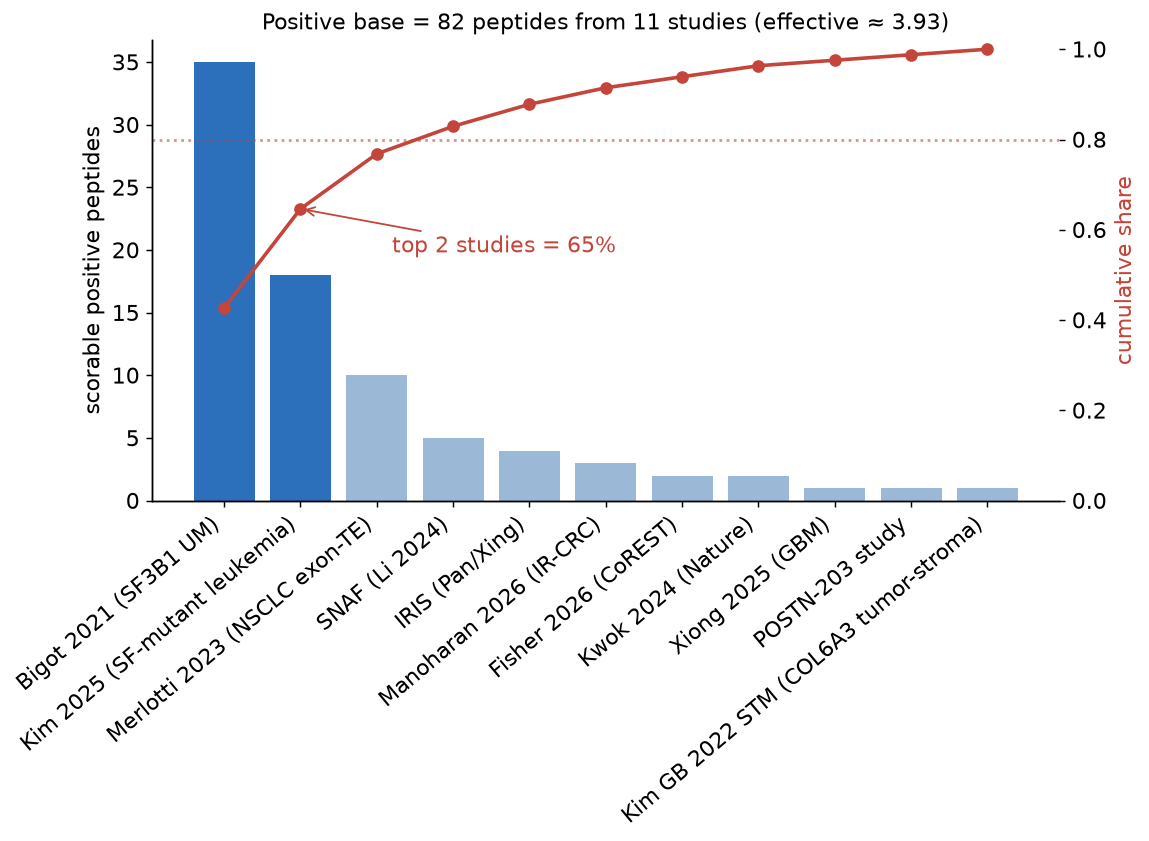

In [5]:
plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 130, "savefig.dpi": 160, "savefig.bbox": "tight"})
ACCENT, MUTE, WARN = "#2c6fbb", "#9bb8d6", "#c4453a"

# --- Figure 1: study Pareto (concentration of the positive base) ---
vc = scorable.study.value_counts()
cum = vc.cumsum() / vc.sum()
fig, ax = plt.subplots(figsize=(9, 4.6))
x = range(len(vc))
ax.bar(x, vc.values, color=[ACCENT if i < 2 else MUTE for i in x])
ax.set_xticks(list(x)); ax.set_xticklabels(vc.index, rotation=40, ha="right")
ax.set_ylabel("scorable positive peptides")
ax.set_title(f"Positive base = {len(scorable)} peptides from {len(vc)} studies "
             f"(effective ≈ {stats['by_study']['effective_n']})", fontsize=12)
ax2 = ax.twinx()
ax2.plot(x, cum.values, color=WARN, marker="o", lw=2)
ax2.set_ylabel("cumulative share", color=WARN); ax2.set_ylim(0, 1.02)
ax2.spines.top.set_visible(False)
ax2.axhline(0.8, ls=":", color=WARN, alpha=0.6)
ax2.annotate("top 2 studies = "
             f"{stats['by_study']['top2_share']:.0%}", (1, cum.values[1]),
             xytext=(2.2, 0.55), color=WARN,
             arrowprops=dict(arrowstyle="->", color=WARN))
fig.savefig(OUT / "fig_study_pareto.png"); plt.show()

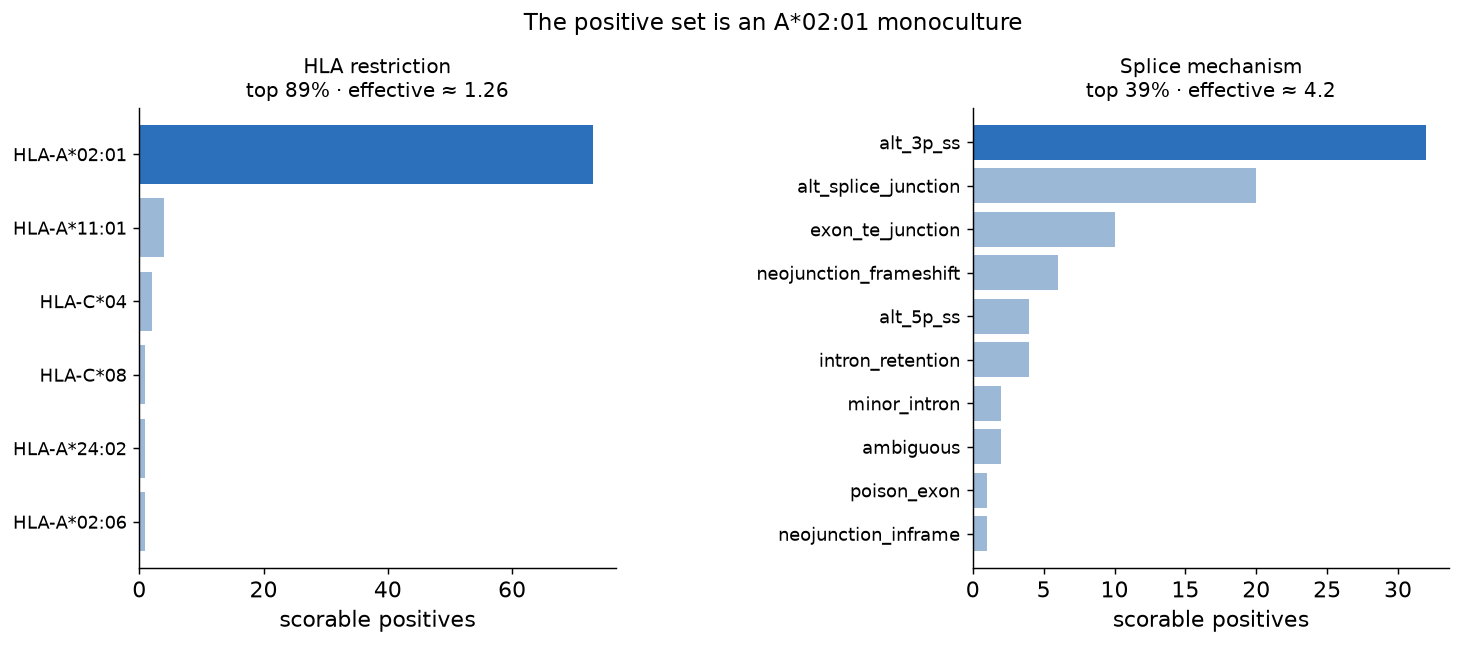

In [6]:
# --- Figure 2: allele monoculture + mechanism skew ---
# Wide figure + generous wspace so the right panel's (long) mechanism labels
# clear the left panel's bars instead of overlapping them.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6),
                         gridspec_kw={"wspace": 0.75})
for ax, key, title in [(axes[0], "hla", "HLA restriction"),
                       (axes[1], "splice_mechanism_canonical", "Splice mechanism")]:
    vc = scorable[key].fillna("(unresolved)").value_counts()
    bars = ax.barh(range(len(vc))[::-1], vc.values,
                   color=[ACCENT] + [MUTE]*(len(vc)-1))
    ax.set_yticks(range(len(vc))[::-1]); ax.set_yticklabels(vc.index, fontsize=10)
    ax.margins(y=0.04)
    eff = (stats['by_allele'] if key == "hla" else stats['by_mechanism'])['effective_n']
    top = (stats['by_allele'] if key == "hla" else stats['by_mechanism'])['top_share']
    ax.set_title(f"{title}\ntop {top:.0%} · effective ≈ {eff}", fontsize=11)
    ax.set_xlabel("scorable positives")
fig.suptitle("The positive set is an A*02:01 monoculture", y=1.04, fontsize=13)
fig.savefig(OUT / "fig_allele_mechanism.png"); plt.show()

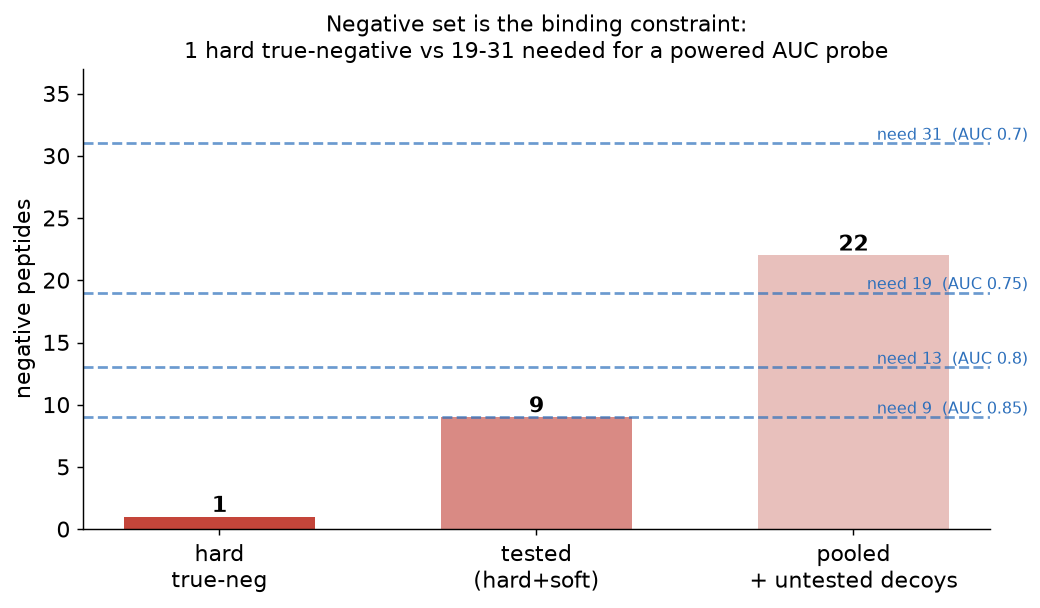

In [7]:
# --- Figure 3: negatives available vs needed ---
fig, ax = plt.subplots(figsize=(9, 4.6))
avail = {"hard\ntrue-neg": hard, "tested\n(hard+soft)": hard + soft,
         "pooled\n+ untested decoys": hard + soft + tier2}
need = stats["power_n_per_arm"]
xa = range(len(avail))
ax.bar(xa, list(avail.values()), color=[WARN, "#d98a84", "#e8c0bc"], width=0.6)
for i, (k, v) in enumerate(avail.items()):
    ax.text(i, v + 0.4, str(v), ha="center", fontweight="bold")
ax.set_xticks(list(xa)); ax.set_xticklabels(avail.keys())
ax.set_ylabel("negative peptides")
for auc, n in need.items():
    ax.axhline(n, ls="--", color=ACCENT, alpha=0.7)
    ax.text(len(avail)-0.45, n + 0.3, f"need {n}  (AUC {auc})",
            color=ACCENT, fontsize=9, ha="right")
ax.set_title("Negative set is the binding constraint:\n"
             f"{hard} hard true-negative vs {need[0.75]}-{need[0.70]} needed "
             "for a powered AUC probe", fontsize=12)
ax.set_ylim(0, max(need.values()) + 6)
fig.savefig(OUT / "fig_negative_scarcity.png"); plt.show()

## 5 · Persist stats

In [8]:
(OUT / "sparsity_stats.json").write_text(json.dumps(stats, indent=2, default=str))
print("wrote", OUT / "sparsity_stats.json")
print(json.dumps({k: v for k, v in stats.items()
                  if k in ("scorable_positives", "negatives", "power_n_per_arm")},
                 indent=2, default=str))

wrote /Users/jin-holee/dev/GitHub/Jin-HoMLee/splice-neoepitope-pipeline-scientist/research/experiments/issue_680_splice_immunogenicity_registry/issue_737_sparsity/outputs/sparsity_stats.json
{
  "scorable_positives": 82,
  "negatives": {
    "hard_true_negative": 1,
    "soft_negative": 8,
    "tested_total": 9,
    "tier2_presented_untested": 13,
    "usable_decoy_ceiling": 22
  },
  "power_n_per_arm": {
    "0.7": 31,
    "0.75": 19,
    "0.8": 13,
    "0.85": 9
  }
}
